## 🌐 **Google Drive Connection**

In [ ]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/[2025-2026]\\ AN2DL/Challenge\\ 2"
%cd $current_dir

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/.shortcut-targets-by-id/1VvyqcN2puDvQNayGrJZr2BIZV4fbj35l/Challenge 2


## ⚙️ **Libraries Import**

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
import torchvision.transforms.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torchvision.models as models
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import albumentations as A # for synchronized augmentation of images and masks

# Install and import torchview for model visualisation
!pip install -q torchview
from torchview import draw_graph

# Configure device and set seeds for CUDA if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")

# Setup directories for models and logs
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import csv
import scipy
from PIL import Image
from xml.dom import minidom
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.9.0+cu126
Device: cuda


## ⏳ **Data Loading**

In [ ]:
# ================================
# Train Dataset
# ================================

# Set environment variables for train dataset
os.environ["TRAIN_ZIP_NAME"] = "train_data.zip"
os.environ["TRAIN_ZIP_ID"]   = "1FQd64ACO4fk--qW4J5wuVSX4sr5kBdSK"

# Check if train dataset exists, download and unzip if not
if not os.path.exists(f"/content/{os.environ['TRAIN_ZIP_NAME']}"):
    print("Downloading train_data.zip...")
    !gdown -q ${TRAIN_ZIP_ID} -O /content/${TRAIN_ZIP_NAME}
    print("train_data.zip downloaded!")

    print("Unzipping train_data.zip...")
    !unzip -qo /content/${TRAIN_ZIP_NAME} -d /content/
    print("train_data unzipped!")
else:
    print("train_data.zip already downloaded and unzipped. Using cached data.")


# ================================
# Test Dataset
# ================================

# Set environment variables for test dataset
os.environ["TEST_ZIP_NAME"] = "test_data.zip"
os.environ["TEST_ZIP_ID"]   = "1gOwuQf-4Xm0YTAHidqy28UYyvOCm6BkA"

# Check if test dataset exists, download and unzip if not
if not os.path.exists(f"/content/{os.environ['TEST_ZIP_NAME']}"):
    print("Downloading test_data.zip...")
    !gdown -q ${TEST_ZIP_ID} -O /content/${TEST_ZIP_NAME}
    print("test_data.zip downloaded!")

    print("Unzipping test_data.zip...")
    !unzip -qo /content/${TEST_ZIP_NAME} -d /content/
    print("test_data unzipped!")
else:
    print("test_data.zip already downloaded and unzipped. Using cached data.")

# ================================
# Labels
# ================================

# Import
labels = pd.read_csv('train_labels.csv')

# Create a column with the numeric labels
labels["label_numeric"] = labels["label"].astype("category").cat.codes

# Create the mapping
int_to_label = dict(enumerate(labels["label"].astype("category").cat.categories))

train_data.zip already downloaded and unzipped. Using cached data.
test_data.zip already downloaded and unzipped. Using cached data.


In [ ]:
IMG_SIZE = 224
def extract_index(filename):
    return filename.split("_")[1].split(".")[0]


def load_images_from_folder(folder):
    """
    Load images and masks from a folder.
    Masks are recognized by filename starting with 'mask'.

    Returns:
        images: np.ndarray (N, 224,224,3)
        masks:  np.ndarray (N, 224,224,1) or empty array if none found
    """
    images_dictionary = {}
    masks_dictionary = {}

    # Iterate through files in the specified folder
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))

        if img is None:
            continue

        idx = extract_index(filename)

        # MASK
        if filename.lower().startswith("mask"):
            # If mask is RGB, take only one channel
            if len(img.shape) == 3:
                img = img[..., 0]

            # Resize using nearest neighbor
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

            # Expand to (H, W, 1)
            img = img[:, :, None].astype(np.float32)

            masks_dictionary[idx] = img

        # IMAGE
        elif filename.lower().startswith("img"):
            # Normalize image pixel values to a float range [0, 1]
            img = img.astype(np.float32)

            # Convert image from BGR to RGB
            if img.shape[-1] == 3:
                img = img[..., ::-1]

            # Resize the image to 224x224 pixels
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images_dictionary[idx] = img

    # Sanity check
    assert sorted(images_dictionary.keys()) == sorted(masks_dictionary.keys())

    keys = sorted(images_dictionary.keys())
    images = np.array([images_dictionary[k] for k in keys])
    masks = np.array([masks_dictionary[k] for k in keys])

    return images, masks

In [ ]:
train_path = '/content/train_data/'
train_images, train_masks = load_images_from_folder(train_path)

test_path = '/content/test_data/'
test_images, test_masks = load_images_from_folder(test_path)

In [ ]:
print(f"Train images shape: {train_images.shape}")
print(f"Train mask shape: {train_masks.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test masks shape: {test_masks.shape}")
print(f"Labels shape: {labels.shape}")

Train images shape: (691, 224, 224, 3)
Train mask shape: (691, 224, 224, 1)
Test images shape: (477, 224, 224, 3)
Test masks shape: (477, 224, 224, 1)
Labels shape: (691, 3)


## 🔎 **Exploration and Data Analysis**

In [ ]:
def display_image(idx, axes=None):
    """
    Display image, mask, and overlay for a single ID.
    If axes are provided, draw into them (3 axes vertically).
    Otherwise, create and show a standalone figure.
    """
    idx = min(idx, len(train_images) - 1)
    img = train_images[idx] / 255.0
    mask = train_masks[idx].squeeze() / 255.0

    # Case 1: called alone → create its own figure
    if axes is None:
        fig, axes = plt.subplots(3, 1, figsize=(6,12))

    # IMAGE
    axes[0].imshow(img)
    axes[0].set_title(f"Image {idx}")
    axes[0].axis("off")

    # MASK
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(f"Mask {idx}")
    axes[1].axis("off")

    # OVERLAY
    axes[2].imshow(img)
    axes[2].imshow(mask, cmap="jet", alpha=0.35)
    axes[2].set_title(f"Overlay {idx}")
    axes[2].axis("off")

    # Show only when standalone
    if axes is None:
        plt.tight_layout()


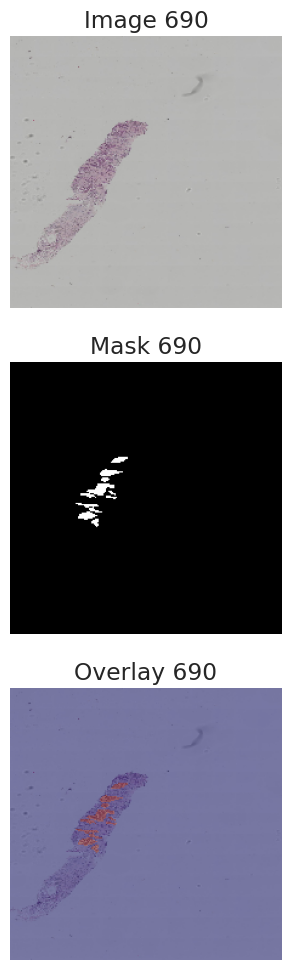

In [ ]:
display_image(1145)

In [ ]:
def display_images_with_masks(num_img=5):
    num_img = min(num_img, len(train_images))

    fig, axes = plt.subplots(3, num_img, figsize=(4*num_img, 12))

    for i in range(num_img):
        col_axes = axes[:, i]
        display_image(i, axes=col_axes)

    plt.tight_layout()
    plt.show()


In [ ]:
display_images_with_masks()

In [ ]:
labels_numeric = labels["label_numeric"].values

print("\nClass distribution:")
for class_idx, class_name in int_to_label.items():
    count = np.sum(labels_numeric == class_idx)
    print(f"  {class_name}: {count} images ({count/len(labels_numeric)*100:.1f}%)")



Class distribution:
  HER2(+): 189 images (27.4%)
  Luminal A: 205 images (29.7%)
  Luminal B: 220 images (31.8%)
  Triple negative: 77 images (11.1%)


##**🧹Pulizia**

In [ ]:
def detect_cartoon_image_hsv(
    img,
    min_frac_area=0.003,
    min_pixels=1500):
    """
    Rileva overlay tipo Shrek/slime usando HSV + area connessa.
    img: np.array (H, W, 3) in [0,1] RGB
    """
    H, W, _ = img.shape
    total = H * W

    # 1)converts to HSV (uint8, 0-255)
    img8 = (img).astype(np.uint8)
    hsv  = cv2.cvtColor(img8, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    green_mask = (
        (h >= 40) & (h <= 90) &
        (s >= 150) &
        (v >= 120)
    ).astype(np.uint8)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        green_mask, connectivity=8)
    max_area = 0
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > max_area:
            max_area = area

    frac_area = max_area / total

    is_cartoon = (max_area >= min_pixels) or (frac_area >= min_frac_area)
    return is_cartoon, frac_area, max_area


In [ ]:
def is_shrek(img, thr=0.05):
    """
    img: una singola immagine del dataset, formato (224,224,3) RGB normalizzato [0,1]
    """
    # Converts [0,1] → [0,255]
    img_uint8 = (img).astype(np.uint8)

    # Converts RGB → BGR to opencv
    img_bgr = img_uint8[:, :, ::-1]

    # Converts to HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    hue        = hsv[:, :, 0]
    saturation = hsv[:, :, 1]
    value      = hsv[:, :, 2]

    mask = (
        (hue >= 10) & (hue <= 40) &
        (saturation >= 120) &
        (value >= 40) & (value <= 200)
    )

    ratio = np.mean(mask)
    return ratio > thr, ratio


In [ ]:
def sensible_detection(img, min_pixels=20):
    """
    Rileva Shrek anche se i pixel sospetti sono pochissimi.
    img: array (H,W,3) in [0,255], RGB
    """
    img8 = img.astype(np.uint8)
    hsv = cv2.cvtColor(img8, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # Shrek green
    green = (
        (h >= 35) & (h <= 100) &
        (s >= 90) &
        (v >= 80)
    )

    # Orange/yellow Shrek
    orange = (
        (h >= 5) & (h <= 35) &
        (s >= 80) &
        (v >= 80)
    )

    mask = green | orange
    suspicious = np.count_nonzero(mask)

    return suspicious >= min_pixels, suspicious


In [ ]:
cartoon_idx = []
normal_idx  = []

for i, img in enumerate(train_images):
    flag, frac_area, max_area = detect_cartoon_image_hsv(img)
    if flag:
        cartoon_idx.append(i)
    else:
        normal_idx.append(i)

print(f"Cartoon images: {len(cartoon_idx)} / {len(train_images)}")
print("Some cartoon indices:", cartoon_idx[:20])

for i in cartoon_idx[:]:
    plt.figure()
    plt.title(f"Candidate cartoon idx {i}")
    plt.imshow(train_images[i]/255)
    plt.axis("off")
    plt.show()

In [ ]:
shrek_indices_train = []
shrek_ratios_train = []

for i, img in enumerate(train_images):
    flag, ratio = is_shrek(img)
    if flag:
        shrek_indices_train.append(i)
        shrek_ratios_train.append(ratio)

print(f"\nTrovate {len(shrek_indices_train)} immagini di Shrek nel train set.")
print("Indici trovati:", shrek_indices_train)

for idx, ratio in zip(shrek_indices_train, shrek_ratios_train):
    plt.figure(figsize=(5,5))
    plt.imshow(train_images[idx]/255.0)
    plt.title(f"TRAIN idx {idx}  |  cartoon_ratio = {ratio:.3f}")
    plt.axis("off")
    plt.show()

In [ ]:
sensible_indices = []
sensible_pixelcounts = []

for i, img in enumerate(train_images):
    flag, suspicious_pixels = sensible_detection(img)
    if flag:
        sensible_indices.append(i)
        sensible_pixelcounts.append(suspicious_pixels)

print(f"\nTrovate {len(sensible_indices)} immagini sensibili/Shrek nel train set (sensible_detection).")
print("Indici trovati:", sensible_indices)

# Visualize all the images found
for idx, suspicious_pixels in zip(sensible_indices, sensible_pixelcounts):
    plt.figure(figsize=(5,5))
    plt.imshow(train_images[idx] / 255.0)   # le immagini sono in [0,255]
    plt.title(f"TRAIN idx {idx}  |  suspicious_pixels = {suspicious_pixels}")
    plt.axis("off")
    plt.show()


In [ ]:
to_remove = set(cartoon_idx) | set(shrek_indices_train) | set(sensible_indices)
print("Totale immagini da rimuovere:", len(to_remove))

all_indices = set(range(len(train_images)))
keep_idx = sorted(list(all_indices - to_remove))

print("Immagini rimanenti:", len(keep_idx))

train_images_clean = train_images[keep_idx]
train_masks_clean  = train_masks[keep_idx]
labels_clean       = labels["label_numeric"].values[keep_idx]

train_images = train_images_clean
train_masks  = train_masks_clean
labels_numeric = labels_clean

Totale immagini da rimuovere: 110
Immagini rimanenti: 581


##**⚖️ Class Imbalance**

In [ ]:
other_labels_numeric = labels["label_numeric"].values

print("\nClass distribution:")
for class_idx, class_name in int_to_label.items():
    count = np.sum(other_labels_numeric == class_idx)
    print(f"  {class_name}: {count} images ({count/len(other_labels_numeric)*100:.1f}%)")



Class distribution:
  HER2(+): 189 images (27.4%)
  Luminal A: 205 images (29.7%)
  Luminal B: 220 images (31.8%)
  Triple negative: 77 images (11.1%)


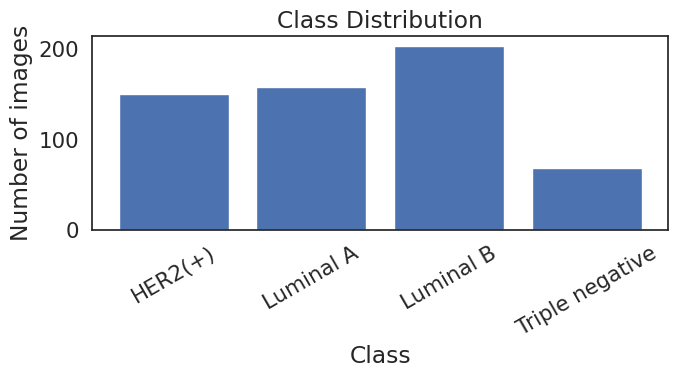

In [ ]:
# Calculation number of samples per class
class_indices = list(int_to_label.keys())
class_names = [int_to_label[i] for i in class_indices]
counts = [np.sum(labels_numeric == i) for i in class_indices]

# Plot
plt.figure(figsize=(7, 4))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
train_images_base   = train_images.copy()
train_masks_base    = train_masks.copy()
labels_numeric_base = labels_numeric.copy()


In [ ]:
train_images   = train_images_base
train_masks    = train_masks_base
labels_numeric = labels_numeric_base

# oversampling
idx_tn = np.where(labels_numeric_base == 3)[0]
print("Original Triple negative:", len(idx_tn))

k = 1
idx_tn_rep = np.repeat(idx_tn, k)

Train_extra = train_images_base[idx_tn_rep]
M_extra     = train_masks_base[idx_tn_rep]
label_extra = labels_numeric_base[idx_tn_rep]

train_images   = np.concatenate([train_images_base, Train_extra], axis=0)
train_masks    = np.concatenate([train_masks_base,  M_extra], axis=0)
labels_numeric = np.concatenate([labels_numeric_base, label_extra], axis=0)

print("After oversampling:")
print("  train_images:", train_images.shape)
print("  train_masks: ", train_masks.shape)
print("  labels_numeric:", labels_numeric.shape)

tn_after = np.sum(labels_numeric == 3)
print("Triple negative AFTER oversampling:", tn_after)

Original Triple negative: 69
After oversampling:
  train_images: (650, 224, 224, 3)
  train_masks:  (650, 224, 224, 1)
  labels_numeric: (650,)
Triple negative AFTER oversampling: 138


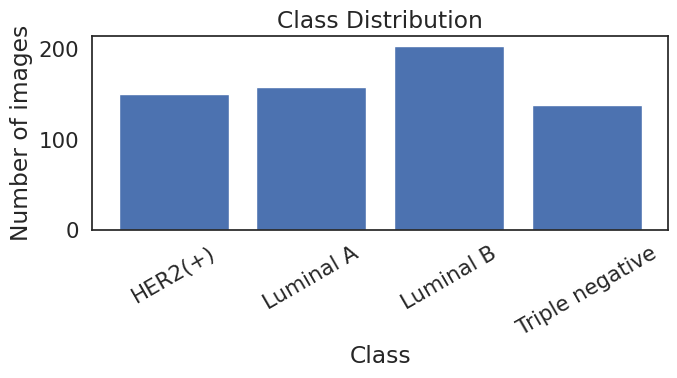

In [ ]:
# Calculation number of samples per class after oversampling
class_indices = list(int_to_label.keys())
class_names = [int_to_label[i] for i in class_indices]
counts = [np.sum(labels_numeric == i) for i in class_indices]

# Plot
plt.figure(figsize=(7, 4))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##**⏫️ Data Augmentation**


In [ ]:
def simple_augmentation(img, mask):
    """Augmentation semplice e affidabile"""

    # Random horizontal flip
    if random.random() > 0.5:
        img = torchvision.transforms.functional.hflip(img)
        mask = torchvision.transforms.functional.hflip(mask)

    # Random vertical flip
    if random.random() > 0.5:
        img = torchvision.transforms.functional.vflip(img)
        mask = torchvision.transforms.functional.vflip(mask)

    # Random rotation (90°, 180°, 270°)
    if random.random() > 0.5:
        angle = random.choice([90, 180, 270])
        img = torchvision.transforms.functional.rotate(
            img, angle,
            interpolation=torchvision.transforms.InterpolationMode.BILINEAR
        )
        mask = torchvision.transforms.functional.rotate(
            mask, angle,
            interpolation=torchvision.transforms.InterpolationMode.NEAREST
        )

    # Light color jitter only on the image
    if random.random() > 0.5:
        img = torchvision.transforms.functional.adjust_brightness(img, random.uniform(0.9, 1.1))
    if random.random() > 0.5:
        img = torchvision.transforms.functional.adjust_contrast(img, random.uniform(0.9, 1.1))

    return img.clamp(0, 1), mask.clamp(0, 1)



##**🧩Patching**

In [ ]:
def detect_tissue_from_image(image, gray_threshold=0.95, std_threshold=0.02):
    """
    Detect tissue regions in histology image (non-background areas).
    Works for images with tissue on gray/black background.

    Args:
        image: numpy array (H, W, 3) normalized [0,1]
        gray_threshold: threshold for gray background (tissue is LESS gray)
        std_threshold: minimum color variation (tissue has more color)

    Returns:
        Binary mask (H, W) where True = tissue
    """
    # Strategy: detect background by LACK of color variation
    # Background is gray/uniform, tissue has purple/pink colors

    # Calculate standard deviation across RGB channels
    # Background (gray) has std ≈ 0, tissue (colored) has std > 0
    color_std = np.std(image, axis=2)

    # Also check if pixels are too dark (black background) or too light (white)
    gray = np.mean(image, axis=2)

    # Tissue = has color variation OR is in mid-range gray
    tissue_mask = (color_std > std_threshold) | ((gray > 0.15) & (gray < gray_threshold))

    # Clean up with morphological operations
    kernel = np.ones((7, 7), np.uint8)
    tissue_mask = cv2.morphologyEx(tissue_mask.astype(np.uint8),
                                    cv2.MORPH_CLOSE, kernel)
    tissue_mask = cv2.morphologyEx(tissue_mask, cv2.MORPH_OPEN, kernel)

    return tissue_mask.astype(bool)

In [ ]:
def extract_patches_hybrid(image, annotation_mask, patch_size=128, stride=64,
                           min_tissue_ratio=0.10, mask_overlap_bonus=2.0):
    """
    HYBRID APPROACH: Extract patches from entire tissue BUT prioritize
    patches that overlap with annotation mask.

    Args:
        image: numpy array (H, W, 3) normalized [0,1]
        annotation_mask: numpy array (H, W, 1) - small annotated region [0,1]
        patch_size: size of square patches
        stride: stride between patches
        min_tissue_ratio: minimum fraction of tissue required (LOWERED to 0.15)
        mask_overlap_bonus: weight multiplier for patches overlapping annotation

    Returns:
        patches: List of patch arrays
        weights: List of sampling weights (higher = more important)
        has_annotation: List of bools (True if patch overlaps annotation)
    """
    H, W, _ = image.shape
    patches = []
    mask_patches=[]
    weights = []
    has_annotation = []

    # Detect all tissue
    tissue_mask = detect_tissue_from_image(image)

    # Binary annotation mask
    annotation_binary = (annotation_mask.squeeze() > 0.1).astype(bool)

    # Sliding window over entire image
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            # Extract patch region masks
            patch_tissue = tissue_mask[y:y+patch_size, x:x+patch_size]
            patch_annotation = annotation_binary[y:y+patch_size, x:x+patch_size]

            # Check if patch has enough tissue
            tissue_ratio = patch_tissue.sum() / (patch_size * patch_size)

            if tissue_ratio >= min_tissue_ratio:
                # Extract the actual image patch
                patch = image[y:y+patch_size, x:x+patch_size, :]
                patch_mask=annotation_mask[y:y+patch_size, x:x+patch_size, :]

                patches.append(patch)
                mask_patches.append(patch_mask)

                # Calculate importance weight
                annotation_ratio = patch_annotation.sum() / (patch_size * patch_size)

                if annotation_ratio > 0:
                    # This patch overlaps with annotation - BOOST its weight
                    weight = 1.0 + (mask_overlap_bonus * annotation_ratio)
                    has_annotation.append(True)
                else:
                    # Normal tissue patch
                    weight = 1.0
                    has_annotation.append(False)

                weights.append(weight)

    return patches, weights, has_annotation, mask_patches

In [ ]:
class HybridPatchingDataset(Dataset):
    """
    Dataset with HYBRID approach:
    - Extracts patches from entire tissue
    - Prioritizes patches overlapping with annotation mask
    - Allows weighted sampling during training
    """

    def __init__(self, images, masks, labels,
                 patch_size=128, patches_per_image=32,
                 augmentation=None, normalize=None,
                 weighted_sampling=True, annotation_boost=2.0, mask_use=None, alpha=0.5):
        """
        Args:
            images: numpy array (N, H, W, 3) normalized [0,1]
            masks: numpy array (N, H, W, 1) - annotation masks [0,1]
            labels: numpy array (N,) with class indices (or None for test)
            patch_size: size of patches (128 o 256 consigliati)
            patches_per_image: patches to sample per image (16-32 consigliati)
            augmentation: torchvision transforms
            normalize: normalization transform
            weighted_sampling: if True, sample annotated patches more often
            annotation_boost: weight multiplier for annotated patches
        """
        self.images = images
        self.masks = masks
        self.labels = labels
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image
        self.augmentation = augmentation
        self.normalize = normalize
        self.weighted_sampling = weighted_sampling
        self.is_test = labels is None
        self.mask_use = mask_use
        self.alpha = alpha

        print(f"\n{'='*60}")
        print(f"HYBRID PATCHING DATASET")
        print(f"{'='*60}")
        print(f"Patch size: {patch_size}x{patch_size}")
        print(f"Patches per image: {patches_per_image}")
        print(f"Weighted sampling: {weighted_sampling} (boost={annotation_boost})")
        print(f"{'='*60}\n")

        # Pre-extract all patches with weights
        print("Extracting patches from all images...")
        self.patch_data = []

        total_patches = 0
        annotated_patches = 0

        for idx in range(len(images)):
            # Extract patches with weights
            patches, weights, has_annot, mask_patches = extract_patches_hybrid(
                images[idx],
                masks[idx],
                patch_size=patch_size,
                stride=patch_size // 2,
                mask_overlap_bonus=annotation_boost
            )

            if len(patches) == 0:
                print(f"  WARNING: Image {idx} produced 0 patches! Extracting center patch as fallback...")
                # FALLBACK: estrai almeno il patch centrale
                H, W = images[idx].shape[:2]
                center_y = max(0, (H - patch_size) // 2)
                center_x = max(0, (W - patch_size) // 2)

                # Assicurati che il patch sia dentro i bounds
                if center_y + patch_size > H:
                    center_y = max(0, H - patch_size)
                if center_x + patch_size > W:
                    center_x = max(0, W - patch_size)

                center_patch = images[idx][center_y:center_y+patch_size, center_x:center_x+patch_size, :]
                center_mask = masks[idx][center_y:center_y+patch_size, center_x:center_x+patch_size, :]
                patches = [center_patch]
                mask_patches = [center_mask]
                weights = [1.0]
                has_annot = [False]

            # Convert weights to sampling probabilities
            weights = np.array(weights)
            probs = weights / weights.sum()

            # Sample patches (weighted if enabled)
            n_patches = min(patches_per_image, len(patches))

            if weighted_sampling and np.any(has_annot):
                # Weighted sampling - favors annotated regions
                sampled_idx = np.random.choice(
                    len(patches),
                    size=n_patches,
                    replace=False,
                    p=probs
                )
            else:
                # Uniform sampling
                sampled_idx = np.random.choice(
                    len(patches),
                    size=n_patches,
                    replace=False
                )

            # Store sampled patches
            for i in sampled_idx:
                patch_info = {
                    'patch': patches[i],
                    'mask':mask_patches[i],
                    'has_annotation': has_annot[i],
                    'weight': weights[i],
                    'image_idx': idx
                }
                if not self.is_test:
                    patch_info['label'] = labels[idx]

                self.patch_data.append(patch_info)

            total_patches += len(patches)
            annotated_patches += sum(has_annot)

            if (idx + 1) % 50 == 0:
                print(f"  Processed {idx + 1}/{len(images)} images")
                print(f"    Total patches so far: {len(self.patch_data)}")
                print(f"    Annotated patches: {sum(p['has_annotation'] for p in self.patch_data)}")

        print(f"\n{'='*60}")
        print(f"EXTRACTION COMPLETE")
        print(f"{'='*60}")
        print(f"Images processed: {len(images)}")
        print(f"Total valid patches found: {total_patches}")
        print(f"Patches with annotation: {annotated_patches} ({100*annotated_patches/max(1,total_patches):.1f}%)")
        print(f"Final dataset size: {len(self.patch_data)} patches")
        print(f"Annotated in dataset: {sum(p['has_annotation'] for p in self.patch_data)}")
        print(f"{'='*60}\n")

        # --- PATCH STATISTICS PER CLASS ---
        if not self.is_test:
            from collections import defaultdict
            stats = defaultdict(lambda: {'total': 0, 'annotated': 0})
            for p in self.patch_data:
                lbl = p['label']
                stats[lbl]['total'] += 1
                if p['has_annotation']:
                    stats[lbl]['annotated'] += 1

            print("\n--- Patch per classe e annotazioni ---")
            for lbl in sorted(stats.keys()):
                total = stats[lbl]['total']
                annotated = stats[lbl]['annotated']
                print(f"Classe {lbl}: {total} patch, {annotated} overlappano con mask ({annotated/total*100:.1f}%)")

    def __len__(self):
        return len(self.patch_data)

    def __getitem__(self, idx):
        item = self.patch_data[idx]
        patch = item['patch']
        mask= item['mask']

        # Convert to tensor (C, H, W)
        patch_tensor = torch.from_numpy(patch).float().permute(2, 0, 1)
        mask_tensor= torch.from_numpy(mask).float().permute(2, 0, 1)


        #Apply augmentation
        if self.augmentation is not None:
          patch_tensor,mask_tensor=self.augmentation(patch_tensor, mask_tensor)


        # Apply normalization
        if self.normalize:
            patch_tensor = self.normalize(patch_tensor)

        # Apply mask use
        if self.mask_use == "attention":
          patch_tensor *= (1 + self.alpha  * mask_tensor)


        if self.is_test:
            # Test set: return only patch (no label)
            return patch_tensor
        else:
            # Train/val set: return patch and label
            label = torch.tensor(item['label']).long()
            return patch_tensor, label

    def get_annotation_stats(self):
        """Utility to check annotation distribution in dataset."""
        annotated = sum(p['has_annotation'] for p in self.patch_data)
        total = len(self.patch_data)
        return {
            'total_patches': total,
            'annotated_patches': annotated,
            'non_annotated_patches': total - annotated,
            'annotation_ratio': annotated / max(1, total)
        }



## ✂️ **Split Dataset**

In [ ]:
# Split into train and validation sets
print("\nSplitting data...")
X_train, X_val, M_train, M_val, y_train, y_val = train_test_split(
    train_images, train_masks, labels_numeric,
    test_size=0.2,
    random_state=SEED,
    stratify=labels_numeric
)

X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32) / 255.0

M_train = (M_train > 0).astype(np.float32)
M_val   = (M_val > 0).astype(np.float32)

test_images = test_images.astype(np.float32) / 255.0
test_masks = (test_masks > 0).astype(np.float32)


# Print shapes of the datasets
print(f"Training Data Shape: {X_train.shape}")
print(f"Training Label Shape: {y_train.shape}")
print(f"Validation Data Shape: {X_val.shape}")
print(f"Validation Label Shape: {y_val.shape}")


Splitting data...
Training Data Shape: (520, 224, 224, 3)
Training Label Shape: (520,)
Validation Data Shape: (130, 224, 224, 3)
Validation Label Shape: (130,)


## ⚙️ **Configuration**

In [ ]:
# Training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
PATIENCE = 50
EPOCHS = 1000

# Regularisation
DROPOUT_RATE = 0.3         # Dropout probability
L1_LAMBDA = 0              # L1 penalty
L2_LAMBDA = 1e-3           # L2 penalty

#PATCHING DATA
patch_size=128
patches_per_image=16
weighted_sampling=True
annotation_boost=4.0

# Define augmentation and normalization for training
train_augmentation = simple_augmentation

train_normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],  # ImageNet mean
    std=[0.229, 0.224, 0.225]    # ImageNet std
)

mask_use = "attention"
 # None | attention | channel

# Set up loss function
from sklearn.utils.class_weight import compute_class_weight

print(f"Configuration:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Patience: {PATIENCE}")
print(f"  Max epochs: {EPOCHS}")

Configuration:
  Image size: 224x224
  Batch size: 64
  Learning rate: 0.0001
  Patience: 50
  Max epochs: 1000


## 🔄 **Data Preprocessing**

### 🎨 **Create DataLoaders**

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """
    Create a PyTorch DataLoader with optimized settings.

    Args:
        ds (Dataset): PyTorch Dataset object
        batch_size (int): Number of samples per batch
        shuffle (bool): Whether to shuffle data at each epoch
        drop_last (bool): Whether to drop last incomplete batch

    Returns:
        DataLoader: Configured DataLoader instance
    """
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [ ]:
train_dataset = HybridPatchingDataset(
    images=X_train,
    masks=M_train,
    labels=y_train,
    patch_size=patch_size,
    patches_per_image=patches_per_image,
    augmentation=train_augmentation,
    normalize=train_normalization,
    weighted_sampling=weighted_sampling,
    annotation_boost=annotation_boost,
    mask_use=mask_use
)

train_loader = make_loader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_dataset = HybridPatchingDataset(
    images=X_val,
    masks=M_val,
    labels=y_val,
    patch_size=patch_size,
    patches_per_image=patches_per_image//2,
    augmentation=None,
    normalize=train_normalization,
    weighted_sampling=weighted_sampling,
    annotation_boost=annotation_boost
)

val_loader = make_loader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

# TEST SET
test_dataset = HybridPatchingDataset(
    images=test_images,
    masks=test_masks,
    labels=None,
    patch_size=patch_size,
    patches_per_image=patches_per_image,
    augmentation=None,
    normalize=train_normalization,
    weighted_sampling=False,

)

test_loader = make_loader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(f"\nClassification DataLoaders created:")
print(f"  Training batches:   {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


HYBRID PATCHING DATASET
Patch size: 128x128
Patches per image: 16
Weighted sampling: True (boost=4.0)

Extracting patches from all images...
  Processed 50/520 images
    Total patches so far: 198
    Annotated patches: 180
  Processed 100/520 images
    Total patches so far: 398
    Annotated patches: 366
  Processed 150/520 images
    Total patches so far: 598
    Annotated patches: 544
  Processed 200/520 images
    Total patches so far: 798
    Annotated patches: 733
  Processed 250/520 images
    Total patches so far: 998
    Annotated patches: 920
  Processed 300/520 images
    Total patches so far: 1198
    Annotated patches: 1102
  Processed 350/520 images
    Total patches so far: 1398
    Annotated patches: 1283
  Processed 400/520 images
    Total patches so far: 1598
    Annotated patches: 1455
  Processed 450/520 images
    Total patches so far: 1798
    Annotated patches: 1640
  Processed 500/520 images
    Total patches so far: 1996
    Annotated patches: 1829

EXTRACTI

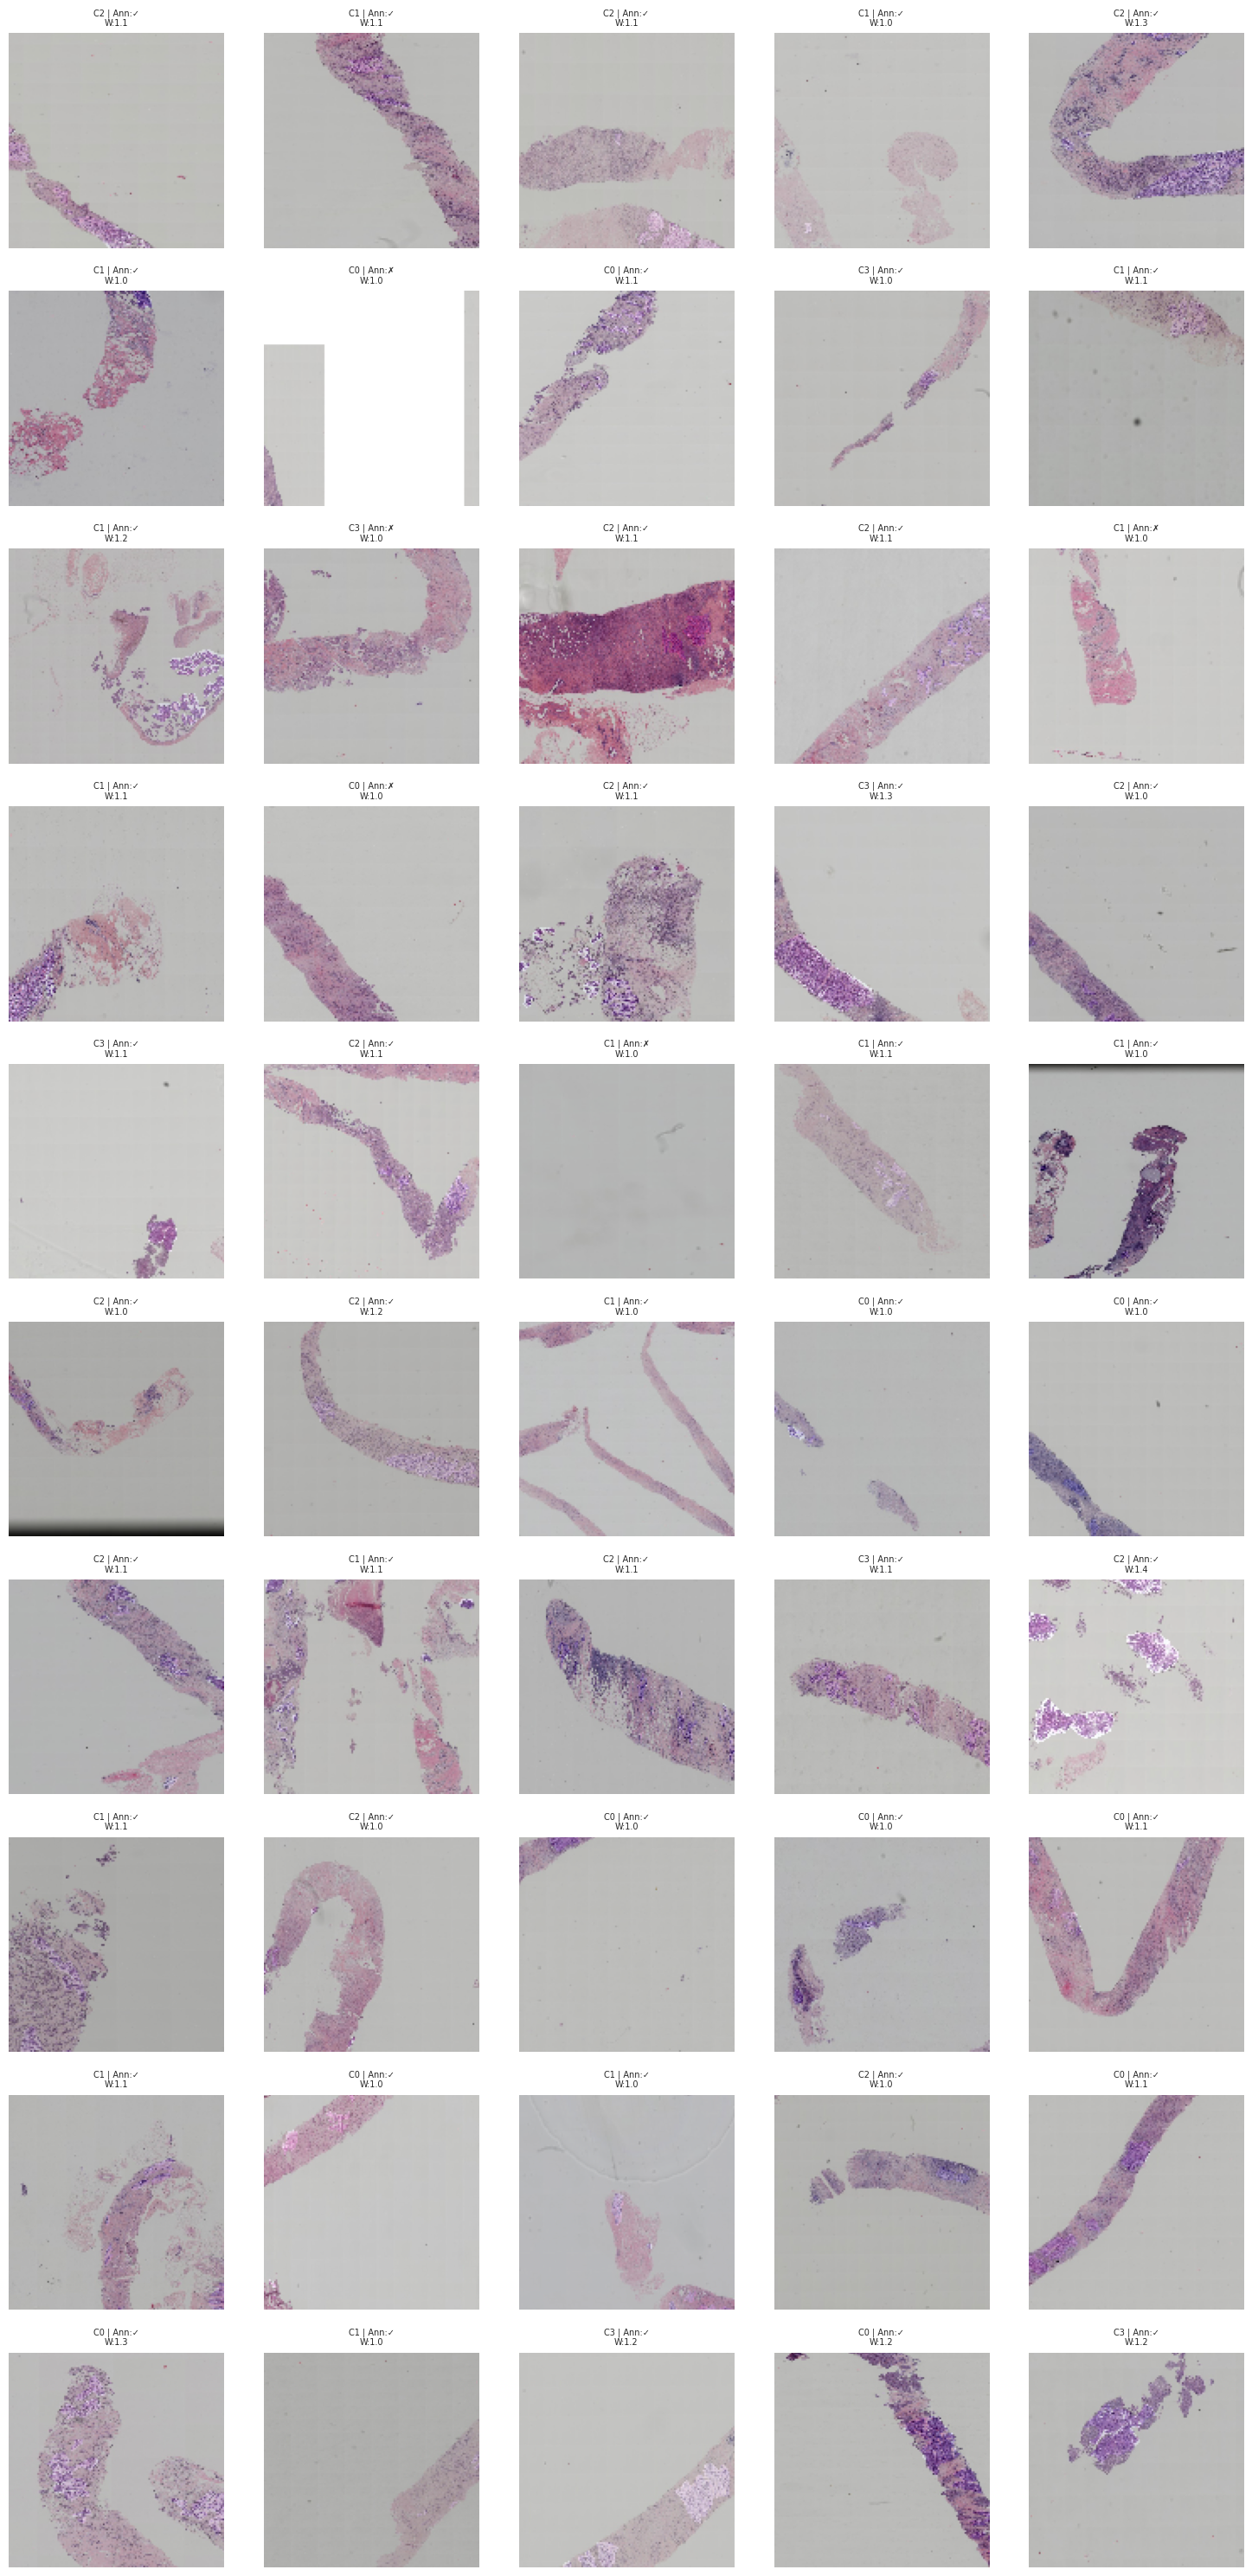

In [ ]:
def display_patch_grid(dataset, num_samples=20, cols=5):
    """
    Mostra patches in una griglia, con denormalizzazione corretta.
    """
    num_samples = min(num_samples, len(dataset))
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten()

    # Samples random indexes
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    # Mean/std to normalize if normalization is active
    if dataset.normalize is not None:
        mean = torch.tensor(dataset.normalize.mean).view(3,1,1)
        std  = torch.tensor(dataset.normalize.std).view(3,1,1)
    else:
        mean = std = None

    for ax, idx in zip(axes, indices):

        if dataset.is_test:
            patch_tensor = dataset[idx]
            label = "Test"
        else:
            patch_tensor, label = dataset[idx]
            label = f"C{label.item()}"

        patch = patch_tensor.clone()

        # correct denomarlization
        if (mean is not None) and (std is not None):
            patch = patch * std + mean

        # clipping
        patch = patch.clamp(0,1)

        # conversion to Numpy (H,W,C)
        patch_rgb = patch.permute(1,2,0).cpu().numpy()

        patch_info = dataset.patch_data[idx]
        has_annot = "✓" if patch_info["has_annotation"] else "✗"

        ax.imshow(patch_rgb)
        ax.set_title(f"{label} | Ann:{has_annot}\nW:{patch_info['weight']:.1f}", fontsize=7)
        ax.axis("off")

    # Hides empty axis
    for ax in axes[num_samples:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Displays patches
display_patch_grid(train_dataset, num_samples=50, cols=5)

In [ ]:
# Get one batch from the training data loader
for xb, yb, *rest in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    if len(rest) > 0:
      mask = rest[0]
      print("Masks batch shape:", mask.shape)
    break  # Stop after getting one batch

Features batch shape: torch.Size([64, 3, 128, 128])
Labels batch shape: torch.Size([64])


## **Weighted loss**

In [ ]:
class_counts = np.bincount(y_train).astype(np.float32)
class_weights = class_counts.sum() / class_counts
class_weights = class_weights / class_weights.mean()

alpha = 1.0

# effect tuning
class_weights = class_weights ** alpha


## 🛠️ **DENSENET121**

In [ ]:
input_shape = tuple(train_dataset[0][0].shape)
num_classes = len(np.unique(y_train))

input_shape

(3, 128, 128)

In [ ]:
NUM_CLASSES = num_classes

model = models.densenet121(pretrained=True)

in_feats = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.5),
    nn.Linear(256, 4)
)

model = model.to(device)

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=0.1)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Verify the model
input_shape = (3, 224, 224)
x = torch.randn(1, *input_shape).to(device)
model.eval()
with torch.no_grad():
    output = model(x)
print(f" Output: {output.shape}")  # [1, 4]
print(f" Params: {sum(p.numel() for p in model.parameters()):,}")

# TensorBoard
experiment_name = "densenet121_pretrained"
writer = SummaryWriter("./logs/"+experiment_name)
writer.add_graph(model, x)


 Output: torch.Size([1, 4])
 Params: 7,217,796


## 🧊**DEFREEZING**

In [ ]:
def configure_model_phase(model, phase='phase1'):
    """
    phase='phase1': Solo classifier trainable
    phase='phase2': Classifier + denseblock4 trainable
    """
    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    if phase == 'phase1':
        # Unfreeze only the classifier
        for param in model.classifier.parameters():
            param.requires_grad = True
        print("✅ PHASE 1: Training only classifier")

    elif phase == 'phase2':
        # Unfreeze denseblock4
        for name, param in model.features.named_parameters():
            if 'denseblock4' in name:
                param.requires_grad = True

        # Unfreeze classifier
        for param in model.classifier.parameters():
            param.requires_grad = True
        print("✅ PHASE 2: Training denseblock4 + classifier")

    # print info
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"   Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
    return model

In [ ]:
PHASE1_EPOCHS = 50
PHASE2_EPOCHS = 950
TOTAL_EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS

EARLY_STOP_PATIENCE = PATIENCE

# optimizer phase 1
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4,
    weight_decay=2e-3
)

# scheduler
scheduler = ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=7,
    min_lr=1e-6
)

model = configure_model_phase(model, phase='phase1')

# Scaler per mixed precision
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

phase2_config = {
    'unfreeze_layers': ['denseblock4'],
    'backbone_lr': 1e-5,
    'classifier_lr': 1e-4
}

print(f"\n📊 Training plan:")
print(f"   Phase 1: epochs 1-{PHASE1_EPOCHS} (classifier only)")
print(f"   Phase 2: epochs {PHASE1_EPOCHS+1}-{TOTAL_EPOCHS} (classifier + denseblock4)")
print(f"   Early stopping patience: {EARLY_STOP_PATIENCE} epochs")
print(f"   Expected stop: ~150 epochs\n")

✅ PHASE 1: Training only classifier
   Trainable: 263,940 / 7,217,796 (3.7%)

📊 Training plan:
   Phase 1: epochs 1-50 (classifier only)
   Phase 2: epochs 51-1000 (classifier + denseblock4)
   Early stopping patience: 50 epochs
   Expected stop: ~150 epochs



In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

## 🚆**TRAINING**

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, batch in enumerate(train_loader):
        if len(batch) == 3:
            inputs, targets, masks = batch
        else:
            inputs, targets = batch
            masks = None

        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for batch in val_loader:
            if len(batch) == 3:
                inputs, targets, masks = batch
            else:
                inputs, targets = batch
                masks = None

            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model, optimizer=None):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)
        optimizer (torch.optim, optional): Optimizer for logging learning rates
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log learning rates
    if optimizer is not None:
        for i, param_group in enumerate(optimizer.param_groups):
            group_name = param_group.get('name', f'group_{i}')
            writer.add_scalar(f'LearningRate/{group_name}', param_group['lr'], epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                if param.grad.numel() > 0:
                    if torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=12, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=1, experiment_name="",
        scheduler=None, phase1_epochs=30, phase2_config=None):

    training_history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    current_phase = 1 if phase1_epochs > 0 else None

    print(f"Training {epochs} epochs...")
    if phase1_epochs > 0:
        print(f"  Phase 1: epochs 1-{phase1_epochs} (classifier only, lr=5e-4)")
        print(f"  Phase 2: epochs {phase1_epochs+1}-{epochs} (denseblock4+classifier)")

    for epoch in range(1, epochs + 1):

        # ========== PHASE TRANSITION ==========
        if phase1_epochs > 0 and epoch == phase1_epochs + 1:
            print("\n" + "="*70)
            print(f"🔄 SWITCHING TO PHASE 2 at epoch {epoch}")
            print("="*70 + "\n")

            current_phase = 2

            # Unfreeze denseblock4
            for name, param in model.features.named_parameters():
                if 'denseblock4' in name:
                    param.requires_grad = True

            # Counts parameters
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            total = sum(p.numel() for p in model.parameters())
            print(f"✅ Unfrozen: denseblock4 + classifier")
            print(f"   Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

            # new optimizer
            backbone_params = [p for name, p in model.features.named_parameters()
                             if 'denseblock4' in name and p.requires_grad]
            classifier_params = list(model.classifier.parameters())

            optimizer = torch.optim.AdamW([
                {'params': backbone_params, 'lr': 5e-6, 'name': 'backbone'},
                {'params': classifier_params, 'lr': 5e-5, 'name': 'classifier'}
            ], weight_decay=1e-2)

            print(f"   LR: backbone=5e-6, classifier=5e-5, wd=1e-2")

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', factor=0.5, patience=5,
                min_lr=1e-7
            )
            patience_counter = 0

        # ========== TRAINING & VALIDATION ==========
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda)
        val_loss, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # TensorBoard
        if writer is not None:
            log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model, optimizer)
            gap = train_f1 - val_f1
            writer.add_scalar('Metrics/train_val_gap', gap, epoch)


        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_f1)
            else:
                scheduler.step()

        # Print progress
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1 or epoch == phase1_epochs):
            phase_str = f"[PHASE {current_phase}] " if current_phase else ""
            gap = train_f1 - val_f1
            print(f"{phase_str}Epoch {epoch:3d}/{epochs} | Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | "
                  f"Val: Loss={val_loss:.4f}, F1={val_f1:.4f} | Gap: {gap:.4f}")

            # LR
            if len(optimizer.param_groups) > 1:
                print(f"   LR: backbone={optimizer.param_groups[0]['lr']:.2e}, "
                      f"classifier={optimizer.param_groups[1]['lr']:.2e}")
            else:
                print(f"   LR: {optimizer.param_groups[0]['lr']:.2e}")


        # Early stopping
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                improvement = current_metric - best_metric if mode == 'max' else best_metric - current_metric
                best_metric = current_metric
                best_epoch = epoch
                torch.save({
                    'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_metric': best_metric, 'phase': current_phase
                }, f"models/{experiment_name}_model.pt")
                patience_counter = 0
            else:
                patience_counter += 1

                if patience_counter >= patience:
                    print(f"\n Early stopping at epoch {epoch}")
                    print(f"   Best val_f1: {best_metric:.4f} (epoch {best_epoch})")
                    break

    # Restore best weights
    if restore_best_weights and patience > 0:
        checkpoint = torch.load(f"models/{experiment_name}_model.pt")
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"\n Best model:  {best_epoch} (Phase {checkpoint.get('phase', 1)})")
        print(f"   val_f1: {best_metric:.4f}")

    return model, training_history


In [ ]:
%%time
# Train model and track training history
densenet_model, densenet_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=TOTAL_EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="DenseNet121_pretrained",
    patience=PATIENCE,
    scheduler=scheduler,
     phase1_epochs=PHASE1_EPOCHS,
    phase2_config=phase2_config
)

# Update best model if current performance is superior
if densenet_history['val_f1'][-1] > best_performance:
    best_model = densenet_model
    best_performance = densenet_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(densenet_history['val_f1']) * 100, 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 1000 epochs...
  Phase 1: epochs 1-50 (classifier only, lr=5e-4)
  Phase 2: epochs 51-1000 (denseblock4+classifier)
[PHASE 1] Epoch   1/1000 | Train: Loss=1.5519, F1=0.2682 | Val: Loss=1.4241, F1=0.2718 | Gap: -0.0036
   LR: 5.00e-04
[PHASE 1] Epoch   2/1000 | Train: Loss=1.4444, F1=0.3226 | Val: Loss=1.4030, F1=0.3033 | Gap: 0.0193
   LR: 5.00e-04
[PHASE 1] Epoch   3/1000 | Train: Loss=1.4023, F1=0.3462 | Val: Loss=1.3911, F1=0.3021 | Gap: 0.0441
   LR: 5.00e-04
[PHASE 1] Epoch   4/1000 | Train: Loss=1.3695, F1=0.3590 | Val: Loss=1.4027, F1=0.2785 | Gap: 0.0805
   LR: 5.00e-04
[PHASE 1] Epoch   5/1000 | Train: Loss=1.3423, F1=0.3805 | Val: Loss=1.3902, F1=0.3147 | Gap: 0.0658
   LR: 5.00e-04
[PHASE 1] Epoch   6/1000 | Train: Loss=1.3411, F1=0.3701 | Val: Loss=1.3676, F1=0.3181 | Gap: 0.0520
   LR: 5.00e-04
[PHASE 1] Epoch   7/1000 | Train: Loss=1.3259, F1=0.3869 | Val: Loss=1.3678, F1=0.3132 | Gap: 0.0737
   LR: 5.00e-04
[PHASE 1] Epoch   8/1000 | Train: Loss=1.2982, F1=0.385

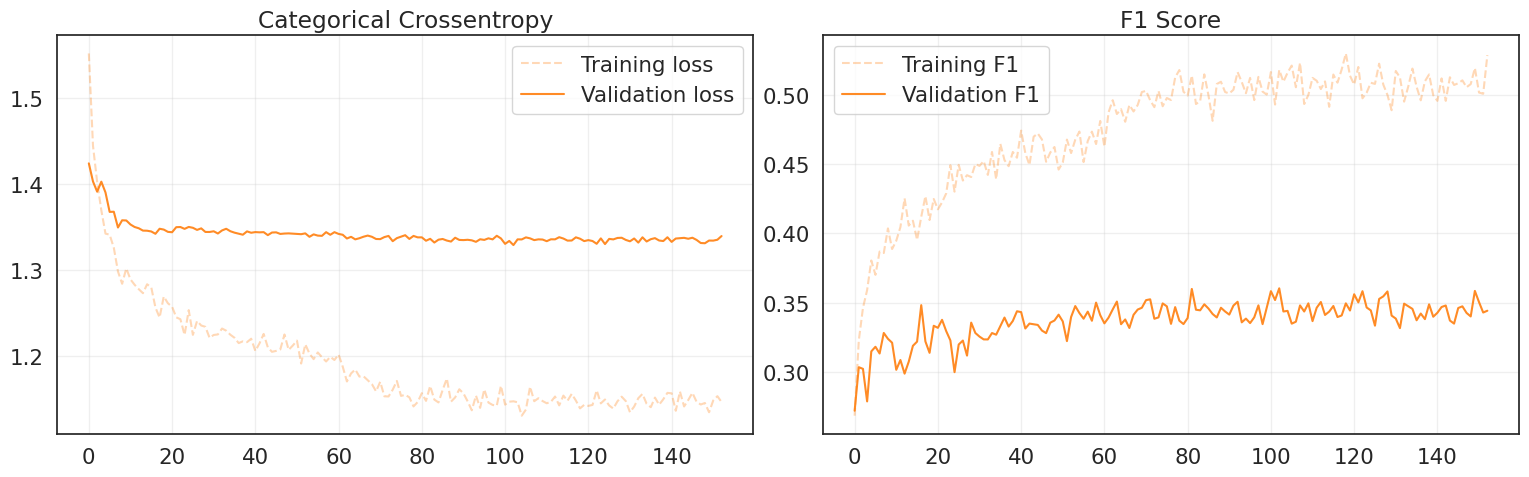

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(densenet_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(densenet_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation F1 score on the second axis
ax2.plot(densenet_history['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(densenet_history['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Generating confusion matrix...


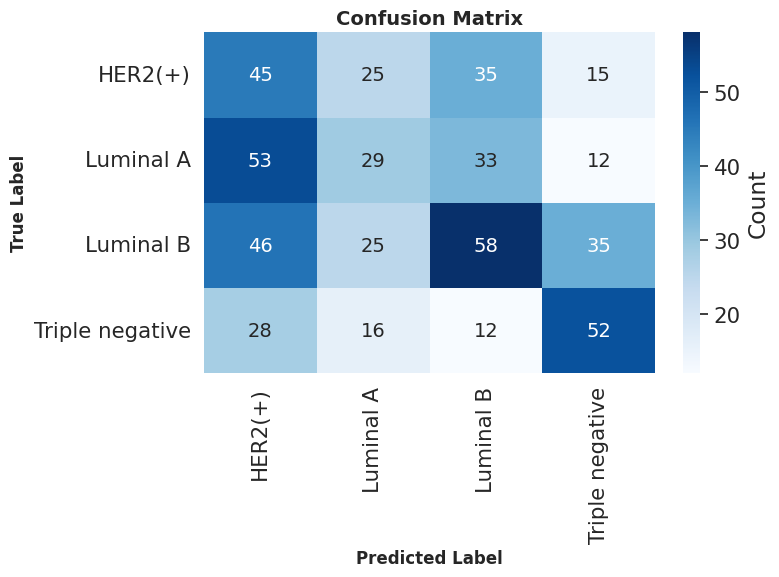

In [ ]:
def plot_confusion_matrix(model, loader, class_names):
    """
    Compute and plot confusion matrix.

    Args:
        model: Trained classifier
        loader: Validation DataLoader
        class_names: Dictionary mapping class indices to names
    """
    model.eval()
    all_preds = []
    all_targets = []

    # Collect predictions
    with torch.no_grad():
        for img, lbl in loader:
            img, lbl = img.to(device), lbl.to(device)
            out = model(img)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(lbl.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_targets, all_preds)

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(class_names.values()),
                yticklabels=list(class_names.values()),
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Generate confusion matrix
print("Generating confusion matrix...")
plot_confusion_matrix(model, val_loader, int_to_label)

## **TEST TIME AUGMENTATION**

Creates 3 possible configurations:
1) flip H+V
2) flip H+V + rotations
3) flip H+V + rotations + regulation brightness/contrast

In [ ]:
import torchvision.transforms.functional as F

# jitter
def jitter_bc_4ch(x, b=0.05, c=0.05):
    if x.shape[1] == 4:
        rgb  = x[:, :3, :, :]
        mask = x[:, 3:, :, :]
    else:
        rgb  = x
        mask = None

    bright_factor   = 1.0 + (2*b)*(torch.rand(1).item() - 0.5)
    contrast_factor = 1.0 + (2*c)*(torch.rand(1).item() - 0.5)

    rgb_j = F.adjust_brightness(rgb, bright_factor)
    rgb_j = F.adjust_contrast(rgb_j, contrast_factor)

    if mask is not None:
        return torch.cat([rgb_j, mask], dim=1)
    else:
        return rgb_j


# TTA transforms
def tta_transforms(x, mode="flip"):
    """
    x: tensor (B, C, H, W)
    mode:
      - "flip"    -> H+V flips
      - "full"    -> H+V + 90/180/270 rotations
      - "full_bc" -> come "full" + leggero brightness/contrast jitter su RGB
    """
    tta = [x]

    if mode in ["flip", "full", "full_bc"]:
        tta.append(torch.flip(x, dims=[3]))      # hflip
        tta.append(torch.flip(x, dims=[2]))      # vflip

    if mode in ["full", "full_bc"]:
        tta.append(torch.rot90(x, k=1, dims=[2, 3]))
        tta.append(torch.rot90(x, k=2, dims=[2, 3]))
        tta.append(torch.rot90(x, k=3, dims=[2, 3]))

    # brightness/contrast
    if mode == "full_bc":
        jittered = []
        for img_batch in tta:
            jb = jitter_bc_4ch(img_batch, b=0.05, c=0.05)
            jittered.append(jb)
        tta = jittered

    return tta


Evaluates TTA on validation

In [ ]:
def evaluate_tta_on_val(model, val_loader, device, mode="flip"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            tta_imgs = tta_transforms(xb, mode=mode)
            logits_sum = 0
            for x_tta in tta_imgs:
                logits_sum += model(x_tta)

            logits_mean = logits_sum / len(tta_imgs)
            preds = logits_mean.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return macro_f1


Tuning

In [ ]:
modes = ["flip", "full", "full_bc"]
best_mode = None
best_score = -1.0

for m in modes:
    score = evaluate_tta_on_val(best_model, val_loader, device, mode=m)
    print(f"TTA mode {m}: macro-F1 = {score:.4f}")
    if score > best_score:
        best_score = score
        best_mode = m

print(f"\nBest TTA mode on validation: {best_mode} (macro-F1 = {best_score:.4f})")

TTA mode flip: macro-F1 = 0.3641
TTA mode full: macro-F1 = 0.3786
TTA mode full_bc: macro-F1 = 0.1383

Best TTA mode on validation: full (macro-F1 = 0.3786)


## **🕹️ Use the Model - Make Inference**

In [ ]:
from tqdm import tqdm
from collections import defaultdict

def predict_test_set(model, test_dataset, device='cuda', batch_size=64,
                     aggregation='max_confidence', num_workers=4,
                     tta_mode="none"):
    """
    Predice le classi per il test set usando patching ibrido.
    Ogni immagine ha multipli patches, quindi serve aggregare le predizioni.

    Args:
        model: modello PyTorch trainato
        test_dataset: HybridPatchingDataset con labels=None
        device: 'cuda' o 'cpu'
        batch_size: batch size per inferenza
        aggregation: metodo di aggregazione ['soft_voting', 'hard_voting', 'max_confidence']
        num_workers: workers per DataLoader

    Returns:
        final_predictions: array (N_images,) con predizioni finali per ogni immagine
        prediction_details: dict con dettagli per analisi
    """
    model.eval()
    model.to(device)

    # DataLoader
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if device == 'cuda' else False
    )

    print(f"\n{'='*60}")
    print(f"TEST SET INFERENCE")
    print(f"{'='*60}")
    print(f"Total patches: {len(test_dataset)}")
    print(f"Batch size: {batch_size}")
    print(f"Aggregation method: {aggregation}")
    print(f"Device: {device}")
    print(f"{'='*60}\n")

    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
      for patches in tqdm(test_loader, desc="Processing patches"):
        patches = patches.to(device)

        # --- APPLY TTA ---
        augmented_batches = tta_transforms(patches, mode=tta_mode)

        tta_probs = []

        for aug in augmented_batches:
            outputs = model(aug)
            probs = torch.softmax(outputs, dim=1)
            tta_probs.append(probs)

        probs_mean = torch.stack(tta_probs, dim=0).mean(dim=0)

        predictions = torch.argmax(probs_mean, dim=1)

        all_predictions.append(predictions.cpu().numpy())
        all_probabilities.append(probs_mean.cpu().numpy())

    print(f"\nAll patches processed: {len(all_predictions)} patches")

    patch_to_image = []
    for item in test_dataset.patch_data:
        patch_to_image.append(item['image_idx'])
    patch_to_image = np.array(patch_to_image)

    unique_images = np.unique(patch_to_image)
    n_images = len(unique_images)

    all_predictions = np.concatenate(all_predictions, axis=0)
    all_probabilities = np.concatenate(all_probabilities, axis=0)

    print(f"\nAll patches processed: {len(all_predictions)} patches")
    final_predictions = []
    prediction_details = {
        'image_predictions': [],
        'image_probabilities': [],
        'patches_per_image': [],
        'confidence_scores': []
    }

    for img_idx in tqdm(unique_images, desc="Aggregating predictions"):
        # Finds all the patches of the images
        mask = (patch_to_image == img_idx)
        img_predictions = all_predictions[mask]
        img_probabilities = all_probabilities[mask]

        if aggregation == 'soft_voting':
            # Avergaes of the probabilities, then argmax
            avg_probs = np.mean(img_probabilities, axis=0)
            final_pred = np.argmax(avg_probs)
            confidence = np.max(avg_probs)

        elif aggregation == 'hard_voting':
            final_pred = np.bincount(img_predictions).argmax()
            confidence = np.sum(img_predictions == final_pred) / len(img_predictions)
            avg_probs = None

        elif aggregation == 'max_confidence':
            max_conf_idx = np.argmax(np.max(img_probabilities, axis=1))
            final_pred = img_predictions[max_conf_idx]
            confidence = np.max(img_probabilities[max_conf_idx])
            avg_probs = img_probabilities[max_conf_idx]

        else:
            raise ValueError(f"Unknown aggregation method: {aggregation}")

        final_predictions.append(final_pred)

        prediction_details['image_predictions'].append(final_pred)
        prediction_details['image_probabilities'].append(avg_probs if avg_probs is not None else img_probabilities)
        prediction_details['patches_per_image'].append(len(img_predictions))
        prediction_details['confidence_scores'].append(confidence)

    final_predictions = np.array(final_predictions)

    print(f"\n{'='*60}")
    print(f"INFERENCE COMPLETE")
    print(f"{'='*60}")
    print(f"Images predicted: {len(final_predictions)}")
    print(f"Average patches per image: {np.mean(prediction_details['patches_per_image']):.1f}")
    print(f"Average confidence: {np.mean(prediction_details['confidence_scores']):.3f}")
    print(f"\nClass distribution:")
    for cls in range(len(np.bincount(final_predictions))):
        count = np.sum(final_predictions == cls)
        print(f"  Class {cls}: {count} images ({100*count/len(final_predictions):.1f}%)")
    print(f"{'='*60}\n")

    return final_predictions, prediction_details


def save_predictions(predictions, test_filenames, int_to_label, output_path='submission.csv'):
    """
    Salva le predizioni in formato CSV per submission della challenge.

    Args:
        predictions: array (N,) con indici di classe predetti
        test_filenames: lista di nomi file delle immagini test (ordinati!)
        int_to_label: dict che mappa indice -> label string (es. {0: 'benign', 1: 'malignant'})
        output_path: path del file CSV di output
    """
    import csv

    # Converts indexes into label string
    predicted_labels = [int_to_label[int(p)] for p in predictions]

    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["sample_index", "label"])

        for fname, label in zip(test_filenames, predicted_labels):
            writer.writerow([fname, label])

    print(f"\n{'='*60}")
    print(f"SUBMISSION FILE CREATED")
    print(f"{'='*60}")
    print(f"File: {output_path}")
    print(f"Total predictions: {len(predictions)}")
    print(f"\nLabel distribution:")
    for lbl in set(predicted_labels):
        count = predicted_labels.count(lbl)
        print(f"  {lbl}: {count} ({100*count/len(predicted_labels):.1f}%)")
    print(f"\nFirst 5 entries:")
    for i in range(min(5, len(test_filenames))):
        print(f"  {test_filenames[i]} -> {predicted_labels[i]}")
    print(f"{'='*60}\n")


def analyze_predictions(prediction_details, save_path='prediction_analysis.png'):
    """
    Crea visualizzazioni per analizzare le predizioni.

    Args:
        prediction_details: dict ritornato da predict_test_set
        save_path: path per salvare il plot
    """
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    patches_per_img = prediction_details['patches_per_image']
    ax.hist(patches_per_img, bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Number of patches')
    ax.set_ylabel('Number of images')
    ax.set_title(f'Patches per Image Distribution\n(mean={np.mean(patches_per_img):.1f})')
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    confidence = prediction_details['confidence_scores']
    ax.hist(confidence, bins=30, edgecolor='black', alpha=0.7, color='green')
    ax.set_xlabel('Confidence score')
    ax.set_ylabel('Number of images')
    ax.set_title(f'Prediction Confidence Distribution\n(mean={np.mean(confidence):.3f})')
    ax.axvline(np.mean(confidence), color='red', linestyle='--', label='Mean')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    predictions = prediction_details['image_predictions']
    unique_classes = np.unique(predictions)
    class_counts = [np.sum(np.array(predictions) == c) for c in unique_classes]
    ax.bar(unique_classes, class_counts, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of images')
    ax.set_title('Predicted Class Distribution')
    ax.set_xticks(unique_classes)
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1, 1]
    ax.scatter(patches_per_img, confidence, alpha=0.5, s=20)
    ax.set_xlabel('Number of patches')
    ax.set_ylabel('Confidence score')
    ax.set_title('Confidence vs Number of Patches')
    ax.grid(True, alpha=0.3)

    corr = np.corrcoef(patches_per_img, confidence)[0, 1]
    ax.text(0.05, 0.95, f'Correlation: {corr:.3f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\nAnalysis plot saved to: {save_path}")
    plt.close()

predictions, details = predict_test_set(
    best_model,
    test_dataset,
    device=device,
    batch_size=64,
    aggregation='max_confidence',
    tta_mode="flip"
)

test_folder = "/content/test_data"
test_filenames = []
for filename in os.listdir(test_folder):
    if filename.lower().startswith("img"):
        test_filenames.append(filename)
test_filenames = sorted(test_filenames, key=lambda x: int(x.split("_")[1].split(".")[0]))

save_predictions(
    predictions=predictions,
    test_filenames=test_filenames,
    int_to_label=int_to_label,
    output_path='submission.csv'
)


TEST SET INFERENCE
Total patches: 1908
Batch size: 64
Aggregation method: max_confidence
Device: cuda



Processing patches: 100%|██████████| 30/30 [00:06<00:00,  4.66it/s]



All patches processed: 30 patches

All patches processed: 1908 patches


Aggregating predictions: 100%|██████████| 477/477 [00:00<00:00, 38653.82it/s]


INFERENCE COMPLETE
Images predicted: 477
Average patches per image: 4.0
Average confidence: 0.420

Class distribution:
  Class 0: 171 images (35.8%)
  Class 1: 126 images (26.4%)
  Class 2: 117 images (24.5%)
  Class 3: 63 images (13.2%)


SUBMISSION FILE CREATED
File: submission.csv
Total predictions: 477

Label distribution:
  HER2(+): 171 (35.8%)
  Luminal A: 126 (26.4%)
  Luminal B: 117 (24.5%)
  Triple negative: 63 (13.2%)

First 5 entries:
  img_0000.png -> HER2(+)
  img_0001.png -> Luminal B
  img_0002.png -> Luminal B
  img_0003.png -> Triple negative
  img_0004.png -> Luminal B

